# RK4 particle 49 inside the sampled gap

Calculate **one new particle**, initially at **(x/L, y/L) = (0.4400, 0.5805)**, in **magenta (#d000d0)**. Reuse the saved 48-particle RK4 section as context. These guiding-center particles do not interact, so adding one does not require recalculating the others.

The selected point maximized distance to the 240,000 saved RK4 returns on a 251 × 391 grid over x/L ∈ [0.425, 0.450], y/L ∈ [0.557, 0.596]. The clearance is measured again below. This identifies a gap in this finite record; it does not establish an inaccessible region or require a single orbit to fill its area.

This focused study uses **RK4 only**, 5000 normalized forcing cycles and 20 complete steps per cycle, matching the supplied RK4 section. It is a seeding experiment rather than a method-accuracy comparison. No audited reference is computed.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from diagnostics.paths import find_project_root
from diagnostics.poincare_probe import load_rk4_probe, save_rk4_probe
from studies.poincare_periodicity import load_saved_poincare_section
from studies.poincare_probe import (
    RK4ProbeSettings, load_probe_field, probe_contract, integrate_rk4_probe,
    probe_section, probe_clearance, probe_comparison_panel,
)
from visualization.poincare_probe import plot_probe_context, display_probe_viewer, serve_probe_viewer
from visualization.poincare_comparison import export_poincare_panel_comparison

PROJECT_ROOT = find_project_root(Path.cwd())
BASE = PROJECT_ROOT / "notebooks/developements/poincare_section"
STUDY = BASE / "Poincare_RK4_particle_49_gap_5000_cycles_20_steps"
BACKGROUND_STUDY = BASE / "Poincare_RK4_48_radiales_5000_ciclos_20_steps_local"
BACKGROUND_RUN = "local_rk4_48p_5000c_20s_20260920"
RUN_DIRECTORY = STUDY / "results/rk4_particle49_5000c_20s"
VIEW = (0.396, 0.529, 0.119)  # Lower x/L, lower y/L, and square span/L.


## Explicit physical and numerical controls

The checked snapshot contains the original normalized mean and first positive-frequency mode of PHI_2.h5. It preserves its magnetic field, spatial scaling, source selection, interpolation and time dependence. Current public GC/RK4 APIs load these arrays; both the field fingerprint and current numerical-source hashes are saved. The background retains its own frozen source provenance.

Coordinates below are fractions of the periodic cell length **L**, not the characteristic length or gyro-radius **rho**. The original grid has L ≈ 18.84956 in normalized physical coordinates. Initial forcing phase is t = 0. The initial position is deterministic; no random seed is needed. Choose a different output directory when changing settings.

In [2]:
SNAPSHOT_SHA256 = "eae45bb3f0c1ff0ee7d27985eaee6fe753dfc1cc2353e1ae75d3a66e09ed4e0d"
PHYSICAL_SETTINGS = {
    "B_tesla": 1.5,
    "characteristic_length_m": 0.06,
    "source_selection": [0, 1],
    "interpolation_order": 3,
}
SETTINGS = RK4ProbeSettings(
    particle_id=49,
    initial_xy_over_L=(0.4400, 0.5805),
    color="#d000d0",
    cycles=5000,
    steps_per_cycle=20,
    chunk_steps=500,  # Same 25-cycle integration blocks as the saved RK4 run.
    rho=0.3,
    t0=0.0,
    cycle_duration=1.0,
)
print(f"RK4: {SETTINGS.cycles * SETTINGS.steps_per_cycle:,} complete steps; "
      f"h = {SETTINGS.cycle_duration / SETTINGS.steps_per_cycle:g}")


RK4: 100,000 complete steps; h = 0.05


Particle 49: initial x/L, y/L = (0.44, 0.5805)
Initial minimum periodic distance to the saved context: 0.01164235 L
L = 18.849555921530; normalized initial position = [ 8.29380461 10.94216721]


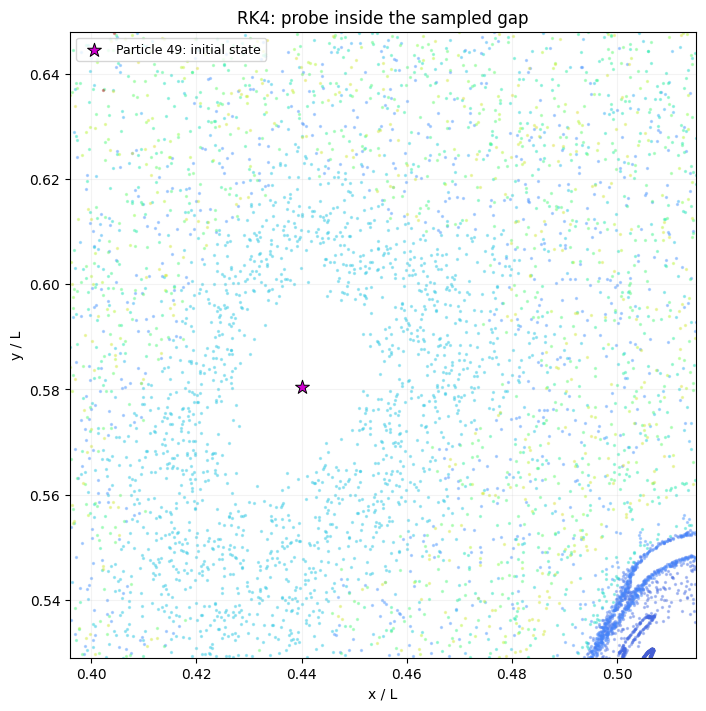

In [3]:
background = load_saved_poincare_section(BACKGROUND_STUDY, BACKGROUND_RUN, tuple(range(1, 49)))
potential, field_provenance = load_probe_field(
    STUDY / "assets/gc2d_snapshot.zip", expected_sha256=SNAPSHOT_SHA256,
    physical_settings=PHYSICAL_SETTINGS,
)
contract = probe_contract(SETTINGS, snapshot_sha256=SNAPSHOT_SHA256,
                          provenance=field_provenance, background=background)
L = field_provenance["grid"]["period"]
clearance = probe_clearance(background, np.array([SETTINGS.initial_xy_over_L]))[0]
print(f"Particle {SETTINGS.particle_id}: initial x/L, y/L = {SETTINGS.initial_xy_over_L}")
print(f"Initial minimum periodic distance to the saved context: {clearance:.8f} L")
print(f"L = {L:.12f}; normalized initial position = {np.array(SETTINGS.initial_xy_over_L) * L}")
display(plot_probe_context(background, SETTINGS, view=VIEW))
plt.close("all")


## Compute or reload the complete trajectory

The first execution integrates only particle 49. Later executions reuse the checksum-verified result if its settings, physical field and numerical-source hashes match. Every RK4 step is saved in float64 (100,001 states for the default run); the section selects one return per complete cycle. Chunking keeps the original clock convention. If interrupted before completion, rerun this cell to calculate again.

In [4]:
if (RUN_DIRECTORY / "COMPLETE.json").exists():
    result, saved_metadata = load_rk4_probe(RUN_DIRECTORY, expected_contract=contract)
    print("Loaded the complete matching RK4 probe run.")
else:
    result = integrate_rk4_probe(potential, SETTINGS)
    save_rk4_probe(RUN_DIRECTORY, result, contract=contract)
    print("Calculated and saved the new RK4 probe run.")

positions = probe_section(result, SETTINGS, L)
assert result["step_count"] == SETTINGS.cycles * SETTINGS.steps_per_cycle
assert positions.shape == (SETTINGS.cycles + 1, 1, 2)
print(f"Saved states: {len(result['times']):,}; cycle returns: {len(positions) - 1:,}")
print(f"Integration wall time: {result['runtime_seconds']:.2f} s")
print(f"Result directory: {RUN_DIRECTORY}")


Loaded the complete matching RK4 probe run.
Saved states: 100,001; cycle returns: 5,000
Integration wall time: 222.43 s
Result directory: /home/juagil@cartif.local/Investigaciones/GC2D/GC2D_codigo/notebooks/developements/poincare_section/Poincare_RK4_particle_49_gap_5000_cycles_20_steps/results/rk4_particle49_5000c_20s


Return bounds x/L: [0.43923059, 0.44143255]
Return bounds y/L: [0.58046454, 0.58386456]
Minimum distance from any new return to the saved context: 0.01016983 L


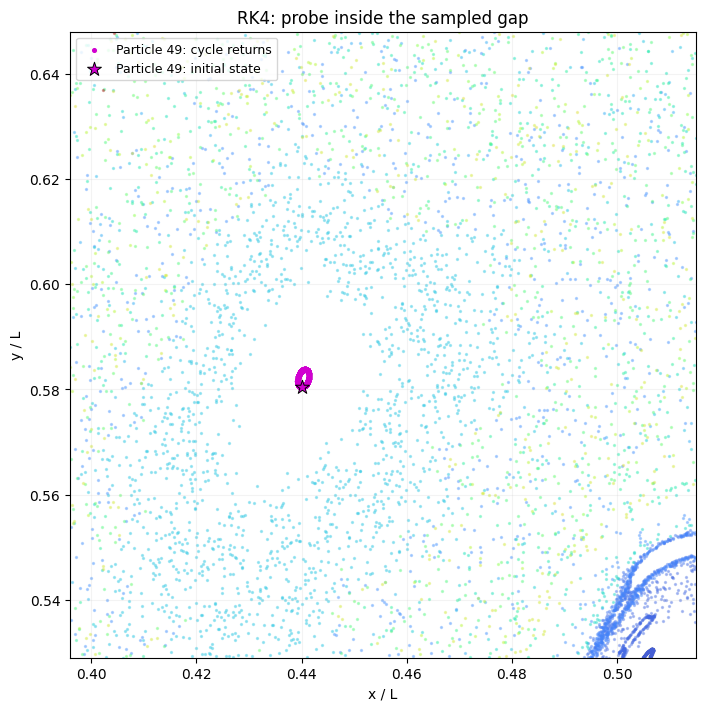

In [5]:
returns = positions[1:, 0]
distances = probe_clearance(background, returns)
print(f"Return bounds x/L: [{returns[:, 0].min():.8f}, {returns[:, 0].max():.8f}]")
print(f"Return bounds y/L: [{returns[:, 1].min():.8f}, {returns[:, 1].max():.8f}]")
print(f"Minimum distance from any new return to the saved context: {distances.min():.8f} L")
figure = plot_probe_context(background, SETTINGS, view=VIEW, positions=positions)
figure.savefig(RUN_DIRECTORY / "particle49_gap.png", dpi=160)
display(figure)
plt.close(figure)


The magenta points show the actual computed returns; no area-filling behavior is imposed. A separated closed-looking curve is compatible with an island in the sampled map but does not by itself prove exact periodicity or numerical accuracy.

Open [visualizacion.ipynb](visualizacion.ipynb) to generate the RK4-only HTML, launch its local URL, isolate particle 49 and select the displayed cycle range. The original RK4 files are only read.